#### **README**

#### K-Means for Watermarking Project
- Put this IPYNB file into VSCode or a similar software
- Python 3.x, NumPy, Matplotlib, and Pillow (PIL) are required to run this code!
- if you do not have these libraries please use the following pip:

**pip install numpy matplotlib pillow**

If these instructions are followed properly, you should be able to run the code and the images will appear underneath!

### **Report**

This project was implemented using Python through an IPYNB file in VSCode using Jupyter Notebooks. To do this lab, I used the given images to start. I then:
- Read in the images
- Divided the images int a 16x16 block size
- Created a K-Means clustering function
- Created a permutation matrix and XOR matrix as keys
- Constructed all the images asked of me in the project details

The accuracy of my code seems good, only the last image being questionable. I worked to try to make the watermark more visable in that image, but to no avail. I struggled A LOT with errors in my code until I was able to finally make a code that ran properly and outputted expected images.

#### **Results**
![Output 1](output1.png)
![Output 2](output2.png)
![Ouput 3](output3.png)
![Output 4](output4.png)
![Output 5](output5.png)

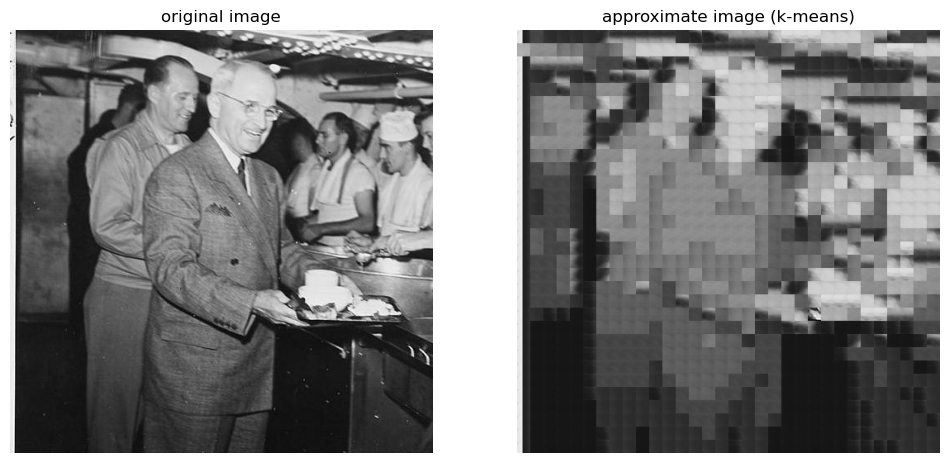

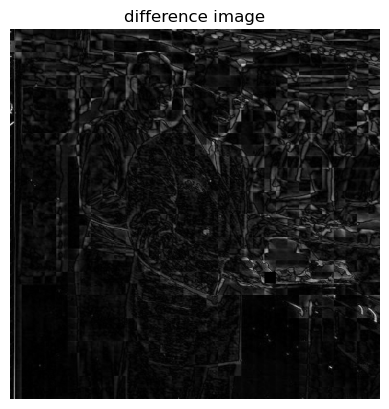

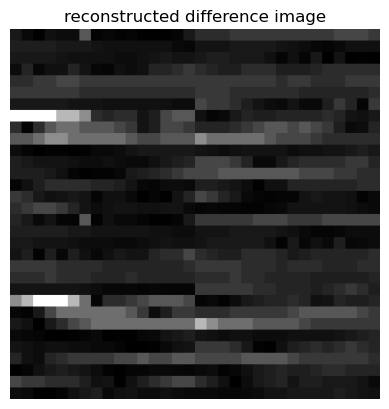

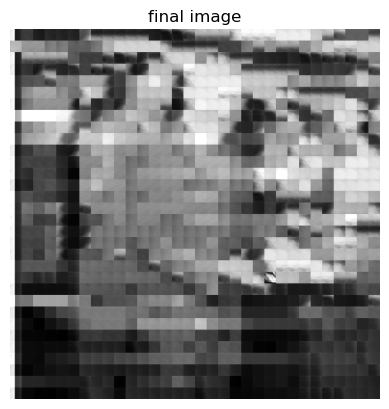

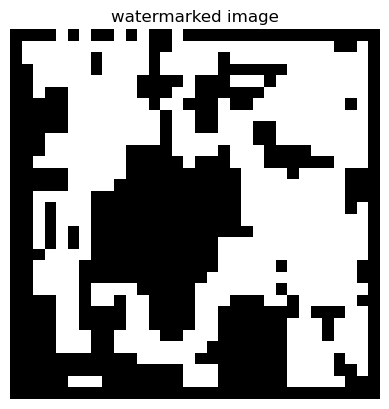

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# step 1: reading in the images
original_image_path = r"D:\KMeans\TrumanEatsLunchII-1.jpg"  # change filename as needed
watermark_image_path = r"D:\KMeans\smiley.jpg"

original_image = Image.open(original_image_path).convert("L")  # convert to grayscale
watermark_image = Image.open(watermark_image_path).convert("L")

original_image = np.array(original_image)
watermark_image = np.array(watermark_image)

# step 2: blocking the image
step = 16  # block size
h, w = original_image.shape
num_blocks = (h // step) * (w // step)
block_vectors = np.zeros((num_blocks, step * step))
k = 0

for i in range(0, h, step):
    for j in range(0, w, step):
        block = original_image[i:i + step, j:j + step]
        block_vectors[k] = block.flatten()
        k += 1

# step 3: k-means clustering
def kmeans(blocks, k, max_iters=100, tol=1e-6):
    centers = blocks[np.random.choice(blocks.shape[0], k, replace=False)]
    
    for _ in range(max_iters):
        distances = np.linalg.norm(blocks[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        old_centers = centers.copy()
        
        for i in range(k):
            if np.any(labels == i):  # prevent mean calculation on empty arrays
                centers[i] = blocks[labels == i].mean(axis=0)
        
        if np.linalg.norm(centers - old_centers) < tol:
            break

    return centers, labels

# run k-means with k=20
K = 20
centers, labels = kmeans(block_vectors, K)

# step 4: create approximate image
approx_image = np.zeros(original_image.shape)
block_idx = 0

for i in range(0, h, step):
    for j in range(0, w, step):
        approx_image[i:i + step, j:j + step] = centers[labels[block_idx]].reshape((step, step))
        block_idx += 1

# display approximate image
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("original image")
plt.imshow(original_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("approximate image (k-means)")
plt.imshow(approx_image, cmap='gray')
plt.axis('off')
plt.show()

# step 5: difference image
difference_image = np.abs(original_image - approx_image)

# display difference image
plt.figure()
plt.title("difference image")
plt.imshow(difference_image, cmap='gray')
plt.axis('off')
plt.show()

# step 6: run k-means on difference image
centers_diff, labels_diff = kmeans(difference_image.flatten().reshape(-1, 1), K)

# step 7: reconstruct approximate difference image
approx_diff_image = np.zeros(original_image.shape)
block_idx = 0

for i in range(0, h, step):
    for j in range(0, w, step):
        approx_diff_image[i:i + step, j:j + step] = centers_diff[labels_diff[block_idx]].reshape((1, 1))  # adjust to 1x1 block
        block_idx += 1

# display reconstructed difference image
plt.figure()
plt.title("reconstructed difference image")
plt.imshow(approx_diff_image, cmap='gray')
plt.axis('off')
plt.show()

# step 8: add the reconstructed images
final_image = np.clip(approx_image + approx_diff_image, 0, 255)

# display final image
plt.figure()
plt.title("final image")
plt.imshow(final_image, cmap='gray')
plt.axis('off')
plt.show()

# step 9: watermarking preparation
binarized_watermark = (watermark_image > 128).astype(int)  # binarize watermark

# ensure watermark size is compatible
if binarized_watermark.shape != (step, step):
    binarized_watermark = np.resize(binarized_watermark, (step, step))

# step 10: k-means on original image for watermark
centers_watermark, labels_watermark = kmeans(block_vectors, K)

# step 11: create indexes matrix
index_matrix = labels.reshape((h // step, w // step))

# step 12: the variance matrix
variance_matrix = np.zeros(index_matrix.shape)

for i in range(1, index_matrix.shape[0] - 1):
    for j in range(1, index_matrix.shape[1] - 1):
        local_indices = index_matrix[i-1:i+2, j-1:j+2].flatten()
        variance_matrix[i, j] = np.var(local_indices)

# step 13: the polarities matrix
threshold = np.median(variance_matrix)
polarities_matrix = (variance_matrix > threshold).astype(int)

# step 14: watermark permutation
permutation_matrix = np.random.permutation(16)
permuted_watermark = np.zeros_like(polarities_matrix)

# ensure the watermark is the same size as polarities_matrix
for i in range(16):
    permuted_watermark[i // (w // step), i % (w // step)] = binarized_watermark[permutation_matrix[i] % 16, permutation_matrix[i] % 16]

# step 15: embedding the watermark
# resize permuted watermark to match polarities_matrix
permuted_watermark_resized = np.resize(permuted_watermark, polarities_matrix.shape)

# perform xor operation
key_2 = np.bitwise_xor(polarities_matrix, permuted_watermark_resized)

# display the watermarked image
plt.figure()
plt.title("watermarked image")
plt.imshow(key_2, cmap='gray')
plt.axis('off')
plt.show()